# 02 · Phase-1 Baselines

Run and compare the three classical baselines on a **temporal split**:

1. **Popularity** (+ recency-weighted / trending variant)
2. **Item-based collaborative filtering**
3. **Matrix factorization (ALS)** — needs the `implicit` package

These set the bar. The real skill you're building: *can a fancier model beat a well-tuned baseline?* Keep this notebook around to re-run that comparison as you add Phase 2–3 models.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from src.recsys.config import settings
from src.recsys.data import load_dataset
from src.recsys.eval import evaluate, temporal_split
from src.recsys.models import ALSRecommender, ItemCFRecommender, PopularityRecommender

ds = load_dataset()
train, test_positives = temporal_split(ds.interactions)
test_users = list(test_positives.keys())
print(ds.summary())
print(f"train interactions: {len(train):,} | test users: {len(test_users):,}")

Dataset(users=800, items=400, interactions=19,847, density=6.2022%, social_edges=4,619, has_images=True)
train interactions: 15,878 | test users: 800


In [2]:
models = {
    "popularity": PopularityRecommender(),
    "popularity_recency": PopularityRecommender(recency_weighted=True),
    "item_cf": ItemCFRecommender(top_n_neighbors=50),
}
try:
    import implicit  # noqa: F401
    models["als"] = ALSRecommender(factors=64, iterations=15)
except ImportError:
    print("implicit not installed -> skipping ALS. Run: pip install implicit")

results = {}
for name, model in models.items():
    model.fit(train)
    recs = model.recommend(test_users, k=settings.top_k)
    results[name] = evaluate(recs, test_positives, ks=settings.eval_ks, n_items=ds.n_items)

results_df = pd.DataFrame(results).T
results_df

/Users/ruobingchen/Projects/recsys-lab/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,recall@5,ndcg@5,hitrate@5,precision@5,coverage@5,recall@10,ndcg@10,hitrate@10,precision@10,coverage@10,recall@20,ndcg@20,hitrate@20,precision@20,coverage@20
popularity,0.028909,0.030253,0.14125,0.02900,0.0225,0.058457,0.044413,0.26375,0.029250,0.0425,0.058457,0.044413,0.26375,0.014625,0.0425
popularity_recency,0.028186,0.027352,0.13000,0.02750,0.0225,0.052048,0.039220,0.22875,0.025625,0.0425,0.052048,0.039220,0.22875,0.012813,0.0425
item_cf,0.223826,0.267439,0.73875,0.22125,0.7425,0.335440,0.315863,0.86000,0.164875,0.8275,0.335440,0.315863,0.86000,0.082437,0.8275
als,0.146735,0.172602,0.56875,0.14475,0.9600,0.228674,0.209383,0.72500,0.113500,0.9875,0.228674,0.209383,0.72500,0.056750,0.9875


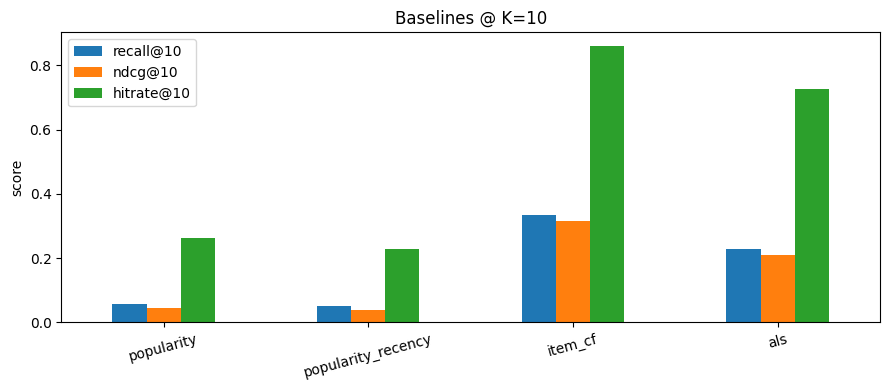

In [3]:
ax = results_df[[f"recall@{settings.top_k}", f"ndcg@{settings.top_k}", f"hitrate@{settings.top_k}"]].plot.bar(
    figsize=(9, 4), rot=15, title=f"Baselines @ K={settings.top_k}"
)
ax.set_ylabel("score"); ax.figure.tight_layout()

## Where to go next

Each of these is a module under `src/recsys/models/` with a documented interface and guidance:

- **Phase 2:** `two_tower.py` (retrieval + FAISS), `ranker.py` (LightGBM re-ranker)
- **Phase 3:** `text_embeddings.py`, `graph.py` (LightGCN), **`social.py` (your priority)**, `multimodal.py`

The workflow stays the same everywhere: `fit(train)` → `recommend(users, k)` → `evaluate(...)`. So you can drop any new model straight into the comparison table above and ask the only question that matters: **did it beat the baseline?**

For the social experiment specifically, also slice metrics by user activity — social signal tends to help sparse users most.